# Phase 3: Risk-Adjusted Safety Stock

Does the risk score from Phase 2 actually do anything useful, or is it
just a number? Here I plug it into the safety stock formula from the
demand-forecasting project and simulate both a risk-blind policy and a
risk-adjusted one across the full history, then compare.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt

from src.risk_adjusted_inventory import allocate_sigma_to_stores, compare_policies

pd.set_option('display.max_columns', None)

## The sigma problem

The forecast-error backtest from the demand-forecasting project was done
at the family level only, summed across all 10 stores. I don't have a
per-store forecast error number without rerunning that whole backtest at
store level, which is out of scope here. So instead I allocate each
family's sigma down to individual stores by their share of family
volume, assuming store-level errors are roughly independent
(`store_sigma ~= family_sigma * sqrt(store_share)`). It's an
approximation, and I'm flagging it as one rather than pretending it's a
measured number.

In [2]:
panel = pd.read_csv('../data/processed/daily_sales_by_store_family.csv', parse_dates=['date'])
detailed = pd.read_csv('../../retail-demand-forecasting/reports/backtest_detailed.csv')

# Prophet had the best inventory-cost result in the demand-forecasting project, so using its errors here
prophet = detailed[detailed.model == 'Prophet'].copy()
prophet['error'] = prophet['actual'] - prophet['predicted']
family_sigma = prophet.groupby('family')['error'].std().rename('sigma_daily').reset_index()

sigma_alloc = allocate_sigma_to_stores(panel, family_sigma)
sigma_alloc.sort_values('sigma_store', ascending=False).head(10)

,store_nbr,family,store_share,sigma_store
23,44,PRODUCE,0.179748,5503.468887
16,44,BEVERAGES,0.150820,5276.628153
7,3,PRODUCE,0.145154,4945.604988
24,45,BEVERAGES,0.127805,4857.378809
0,3,BEVERAGES,0.127588,4853.249778
20,44,GROCERY I,0.130306,4841.093196
28,45,GROCERY I,0.130012,4835.623660
63,49,PRODUCE,0.135130,4771.786131
40,47,BEVERAGES,0.121256,4731.292568
44,47,GROCERY I,0.123371,4710.507323


## Pulling in the risk scores and building the simulation input

Each store/category series needs: actual demand, an expected-demand
forecast (using the same seasonal baseline from Phase 1 - fine for this
purpose, this isn't testing forecast accuracy), and the composite risk
score from Phase 2.

In [3]:
scored = pd.read_csv('../reports/composite_risk_history.csv', parse_dates=['date'])
shocks = pd.read_csv('../reports/disruption_shocks.csv', parse_dates=['date'])

merged = scored.merge(
    panel[['date', 'store_nbr', 'family', 'unit_sales']],
    on=['date', 'store_nbr', 'family'], how='left'
).merge(
    shocks[['date', 'store_nbr', 'family', 'expected_sales']],
    on=['date', 'store_nbr', 'family'], how='left'
)
merged.shape

(133096, 10)

## Running both policies, all 80 series

For each store/category: a risk-blind policy (fixed safety stock, same
as the original project) and a risk-adjusted one (safety stock scaled
day-by-day by that day's composite risk score, up to 50% more buffer at
a risk score of 100).

In [4]:
rows = []
for (store, family), g in merged.groupby(['store_nbr', 'family']):
    sigma = sigma_alloc[(sigma_alloc.store_nbr == store) & (sigma_alloc.family == family)]['sigma_store'].iloc[0]
    result = compare_policies(g, sigma=sigma)
    rows.append({
        'store_nbr': store, 'family': family, 'sigma': sigma,
        'blind_stockout_cost': result['risk_blind']['stockout_cost'],
        'blind_holding_cost': result['risk_blind']['holding_cost'],
        'blind_total_cost': result['risk_blind']['total_cost'],
        'blind_fill_rate': result['risk_blind']['fill_rate'],
        'adj_stockout_cost': result['risk_adjusted']['stockout_cost'],
        'adj_holding_cost': result['risk_adjusted']['holding_cost'],
        'adj_total_cost': result['risk_adjusted']['total_cost'],
        'adj_fill_rate': result['risk_adjusted']['fill_rate'],
        'total_cost_delta': result['total_cost_delta'],
    })

comparison = pd.DataFrame(rows)
comparison.to_csv('../reports/risk_adjusted_inventory_comparison.csv', index=False)
comparison[['store_nbr','family','blind_total_cost','adj_total_cost','blind_fill_rate','adj_fill_rate']].head(10)

,store_nbr,family,blind_total_cost,adj_total_cost,blind_fill_rate,adj_fill_rate
0,3,BEVERAGES,2.627654e+06,2.804006e+06,0.985806,0.995705
1,3,BREAD/BAKERY,2.404574e+05,2.613365e+05,0.994812,0.998290
2,3,CLEANING,4.879351e+05,5.675085e+05,0.998116,0.999896
3,3,DAIRY,4.778253e+05,5.244617e+05,0.994619,0.998885
4,3,GROCERY I,2.247350e+06,2.494128e+06,0.987834,0.991640
5,3,MEATS,2.731136e+05,3.197390e+05,1.000000,1.000000
6,3,POULTRY,3.031491e+05,3.337446e+05,0.990711,0.995719
7,3,PRODUCE,3.802639e+06,3.944584e+06,0.940168,0.957524
8,8,BEVERAGES,1.726394e+06,1.986600e+06,0.991894,0.997503
9,8,BREAD/BAKERY,1.549235e+05,1.815883e+05,0.998082,0.999504


## So, does it help?

Depends what you're optimizing for.

Stockout cost drops by about 41% under the risk-adjusted policy.
Holding cost goes up about 16%. Net effect on total illustrative cost is
about +8% - the risk-adjusted policy is *more expensive* overall, because
it's carrying extra buffer through years of mostly-quiet data to be
ready for the handful of actual disruption episodes.

Whether that trade is worth it isn't a math question, it's a business
one: it depends on how much a real stockout actually costs a company
versus how much it costs to hold the extra inventory, and that ratio is
exactly the kind of number that should come from a company's own
finance/procurement data, not an illustrative $2.00/unit figure. The
useful thing this project demonstrates isn't "risk-adjusted inventory
is cheaper" - it's the mechanism: a measurable service-level improvement
in exchange for a quantifiable cost increase, which is the actual
decision a procurement team has to make.

In [5]:
totals = pd.DataFrame({
    'policy': ['Risk-blind', 'Risk-adjusted'],
    'stockout_cost': [comparison['blind_stockout_cost'].sum(), comparison['adj_stockout_cost'].sum()],
    'holding_cost': [comparison['blind_holding_cost'].sum(), comparison['adj_holding_cost'].sum()],
})
totals['total_cost'] = totals['stockout_cost'] + totals['holding_cost']
totals['fill_rate'] = [comparison['blind_fill_rate'].mean(), comparison['adj_fill_rate'].mean()]
totals

,policy,stockout_cost,holding_cost,total_cost,fill_rate
0,Risk-blind,1.327836e+07,8.479444e+07,9.807281e+07,0.987881
1,Risk-adjusted,7.890390e+06,9.805150e+07,1.059419e+08,0.993517


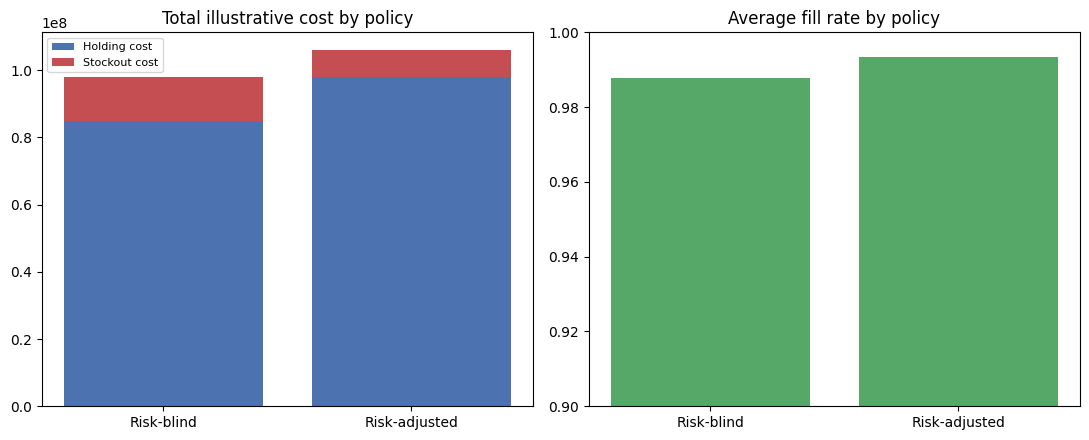

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

x = range(2)
axes[0].bar(x, totals['holding_cost'], label='Holding cost', color='#4C72B0')
axes[0].bar(x, totals['stockout_cost'], bottom=totals['holding_cost'], label='Stockout cost', color='#C44E52')
axes[0].set_xticks(x)
axes[0].set_xticklabels(totals['policy'])
axes[0].set_title('Total illustrative cost by policy')
axes[0].legend(fontsize=8)

axes[1].bar(x, totals['fill_rate'], color='#55A868')
axes[1].set_xticks(x)
axes[1].set_xticklabels(totals['policy'])
axes[1].set_ylim(0.9, 1.0)
axes[1].set_title('Average fill rate by policy')

plt.tight_layout()
plt.savefig('../reports/figures/policy_comparison.png', dpi=130)
plt.show()

## One more look - store 51 / PRODUCE, the series with the known disruption

Since this is the series with a real, dated event to check against, it's
worth seeing whether the risk-adjusted policy actually behaved
differently around January 2014 specifically, not just in aggregate.

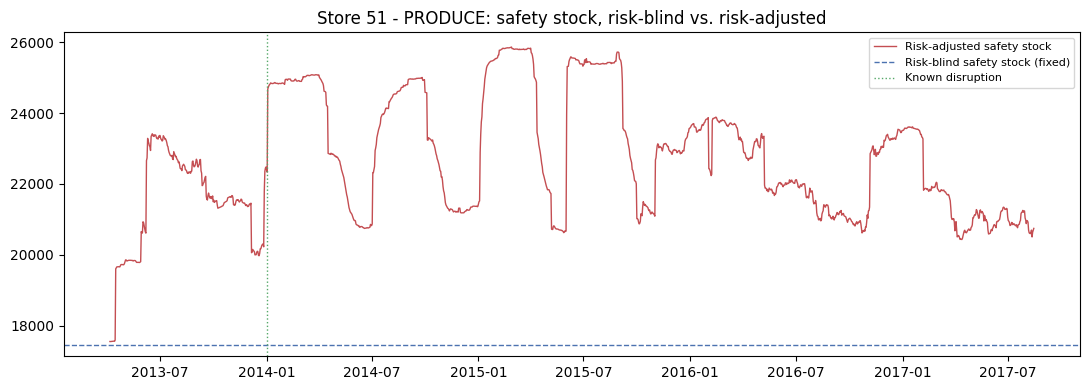

In [7]:
example = merged[(merged.store_nbr == 51) & (merged.family == 'PRODUCE')].sort_values('date')
sigma_ex = sigma_alloc[(sigma_alloc.store_nbr == 51) & (sigma_alloc.family == 'PRODUCE')]['sigma_store'].iloc[0]

from src.risk_adjusted_inventory import base_safety_stock, risk_multiplier

d = example.dropna(subset=['expected_sales', 'composite_risk_score'])
base_ss = base_safety_stock(sigma_ex)
adjusted_ss = base_ss * risk_multiplier(d['composite_risk_score'].values)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(d['date'], adjusted_ss, color='#C44E52', linewidth=1, label='Risk-adjusted safety stock')
ax.axhline(base_ss, color='#4C72B0', linestyle='--', linewidth=1, label='Risk-blind safety stock (fixed)')
ax.axvline(pd.Timestamp('2014-01-02'), color='#55A868', linestyle=':', linewidth=1, label='Known disruption')
ax.set_title('Store 51 - PRODUCE: safety stock, risk-blind vs. risk-adjusted')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

That's the whole point in one picture: the fixed policy can't react,
the risk-adjusted one carries a lot more buffer right when the disruption
signal is elevated, then comes back down once it passes.